# Занятие 01. Первичный анализ внешнего набора данных: Zenodo PMSM inverter fault diagnosis

## Теоретический блок

Набор данных рассматривается как инженерная таблица наблюдений. Наблюдение -
одна строка, соответствующая измеренному или расчетному состоянию объекта.
Признак (feature) - входная величина анализа. Диагностический столбец -
величина, полезная для объяснения источника данных, но потенциально опасная
как вход модели из-за утечки данных (data leakage).

Источник: https://zenodo.org/records/14482932.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "data").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Не найден корень проекта appai_lab.")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_diagnostics.csv"
METADATA_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_metadata.md"
FALLBACK_FEATURES_FILE = DATA_DIR / "practice_02_motor_efficiency_features.csv"
FALLBACK_DIAGNOSTICS_FILE = DATA_DIR / "practice_02_motor_efficiency_diagnostics.csv"

RANDOM_STATE = 20260507
GROUP_COLUMN = "profile_id"
TIME_COLUMN = "time_index"
DATASET_ID = "zenodo_pmsm_inverter_fault"
DATASET_TITLE = "Zenodo PMSM inverter fault diagnosis"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


def load_external_or_fallback():
    if FEATURES_FILE.exists() and DIAGNOSTICS_FILE.exists():
        features = pd.read_csv(FEATURES_FILE)
        diagnostics = pd.read_csv(DIAGNOSTICS_FILE)
        source_status = "external"
    else:
        features = pd.read_csv(FALLBACK_FEATURES_FILE)
        diagnostics = pd.read_csv(FALLBACK_DIAGNOSTICS_FILE)
        source_status = "fallback_base"
    full = features.merge(diagnostics, on="sample_id", how="left", validate="one_to_one")
    return features, diagnostics, full, source_status


def plot_correlation_heatmap(data, columns, title):
    corr = data[columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(max(7, 0.75 * len(columns)), max(5, 0.65 * len(columns))))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Коэффициент корреляции")
    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


def group_holdout_split(data, group_column, test_share=0.25):
    groups = np.array(sorted(data[group_column].dropna().unique()))
    test_count = max(1, int(np.ceil(len(groups) * test_share)))
    test_groups = groups[-test_count:]
    test_mask = data[group_column].isin(test_groups)
    return data.index[~test_mask], data.index[test_mask], test_groups


features_df, diagnostics_df, full_df, source_status = load_external_or_fallback()
print("Источник данных:", source_status)
print("Файл признаков:", FEATURES_FILE if source_status == "external" else FALLBACK_FEATURES_FILE)
print("Размер feature-таблицы:", features_df.shape)
features_df.head()


Источник данных: external
Файл признаков: /mnt/f/projects/appai_lab/data/processed/external/zenodo_pmsm_inverter_fault_features.csv
Размер feature-таблицы: (10892, 11)


,sample_id,profile_id,time_index,speed_rpm,torque_proxy_nm,voltage_v,current_a,ambient_temp_c,temperature_c,max_bridge_temp_c,is_allowed
0,1,1,0.0,95.492966,5.642229,21.994135,6.118761,25.0,11.430371,12.229922,1
1,2,1,0.1,95.492966,5.587977,21.994135,6.126954,25.0,11.954090,12.646151,1
2,3,1,0.2,95.492966,12.912023,21.994135,6.078809,25.0,11.430230,12.229922,1
3,4,1,0.3,95.492966,9.042033,21.994135,6.039383,25.0,11.843363,12.479497,1
4,5,1,0.4,95.492966,5.533724,17.106549,6.022350,25.0,11.320267,12.229922,1


In [2]:
metadata_text = METADATA_FILE.read_text(encoding="utf-8") if METADATA_FILE.exists() else "Метаданные не найдены."
print(metadata_text)


# Zenodo PMSM inverter fault diagnosis

- Идентификатор: `zenodo_pmsm_inverter_fault`.
- Источник: https://zenodo.org/records/14482932.
- Лицензия и доступ: CC BY 4.0.
- Статус подготовки: `prepared`.
- Число строк в компактной учебной выборке: 10892.

Методическое назначение: расширенные блокноты занятий 1-3 с реальными
или открытыми инженерными данными. Feature-CSV используется для базовой
модели, diagnostics-CSV - для пояснения происхождения целевых переменных,
ограничений и возможной утечки данных.

Дополнительные замечания:
- Целевая переменная регрессии: `max_bridge_temp_c`.
- Целевая переменная классификации: `is_allowed`, где `F0` трактуется как нормальная работа.
- `torque_proxy_nm` является расчетным прокси-показателем, полученным из `Power_AC` и фиксированной скорости 10 рад/с.



In [3]:
dataset_passport = pd.DataFrame(
    {
        "field": [
            "dataset_id",
            "title",
            "source_status",
            "rows_features",
            "columns_features",
            "group_column",
            "time_column",
            "regression_target",
            "classification_target",
        ],
        "value": [
            DATASET_ID,
            DATASET_TITLE,
            source_status,
            features_df.shape[0],
            features_df.shape[1],
            GROUP_COLUMN,
            TIME_COLUMN,
            "max_bridge_temp_c",
            "is_allowed",
        ],
    }
)
dataset_passport


,field,value
0,dataset_id,zenodo_pmsm_inverter_fault
1,title,Zenodo PMSM inverter fault diagnosis
2,source_status,external
3,rows_features,10892
4,columns_features,11
5,group_column,profile_id
6,time_column,time_index
7,regression_target,max_bridge_temp_c
8,classification_target,is_allowed


In [4]:
analysis_columns = ['speed_rpm', 'torque_proxy_nm', 'voltage_v', 'current_a', 'ambient_temp_c', 'temperature_c', 'max_bridge_temp_c']
features_df[analysis_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
speed_rpm,10892.0,95.492966,1.421151e-14,95.492966,95.492966,95.492966,95.492966,95.492966
torque_proxy_nm,10892.0,3.671851,4.147226e+00,0.000000,0.542522,1.953079,5.877322,62.661290
voltage_v,10892.0,19.828107,5.742805e+00,2.443793,17.106549,21.994135,21.994135,85.532747
current_a,10892.0,4.941134,2.205677e+00,0.034560,3.446528,5.459785,6.464282,9.781584
ambient_temp_c,10892.0,25.000000,0.000000e+00,25.000000,25.000000,25.000000,25.000000,25.000000
temperature_c,10892.0,14.292217,2.819565e+00,10.415035,12.348347,12.593238,17.346200,20.960235
max_bridge_temp_c,10892.0,17.310130,5.298965e+00,11.401305,13.735092,14.156756,22.517270,32.673387


In [5]:
missing_table = (
    features_df.isna().sum().rename("missing_count").to_frame()
    .assign(missing_share=lambda x: x["missing_count"] / len(features_df))
)
missing_table[missing_table["missing_count"] > 0]


,missing_count,missing_share


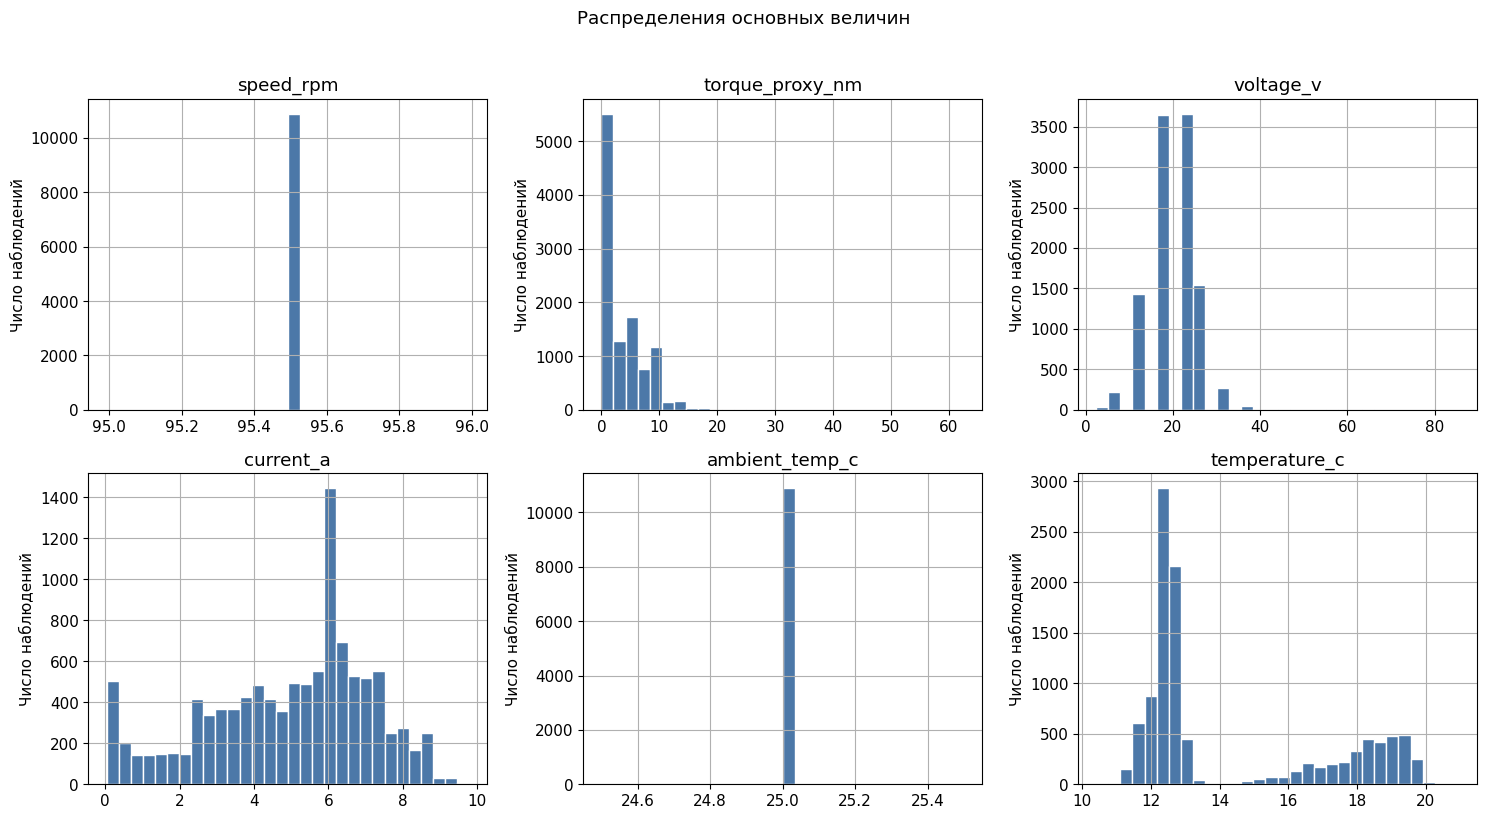

In [6]:
numeric_columns = features_df.select_dtypes(include=[np.number]).columns.tolist()
shown_columns = [column for column in analysis_columns if column in numeric_columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, column in zip(axes, shown_columns[:6]):
    ax.hist(features_df[column].dropna(), bins=30, color="#4c78a8", edgecolor="white")
    ax.set_title(column)
    ax.set_ylabel("Число наблюдений")
for ax in axes[len(shown_columns[:6]):]:
    ax.set_axis_off()
plt.suptitle("Распределения основных величин", y=1.02)
plt.tight_layout()
plt.show()


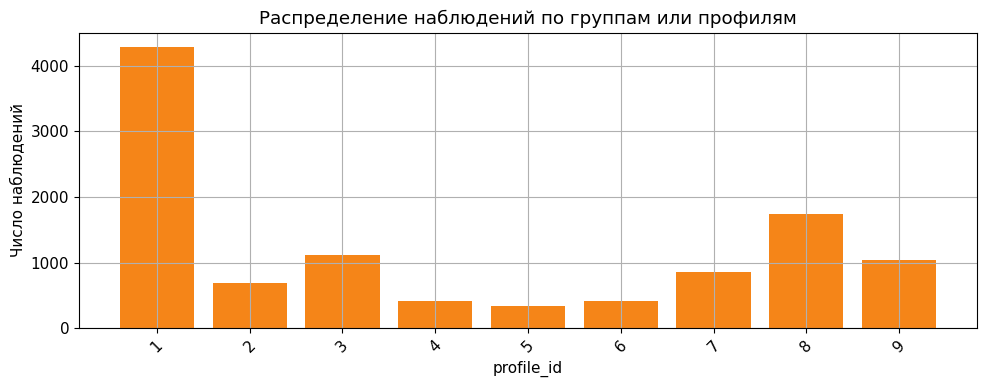

profile_id
1    4295
2     692
3    1122
4     407
5     341
6     412
7     854
8    1735
9    1034
Name: count, dtype: int64

In [7]:
if GROUP_COLUMN in features_df.columns:
    group_counts = features_df[GROUP_COLUMN].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(group_counts.index.astype(str), group_counts.values, color="#f58518")
    ax.set_xlabel(GROUP_COLUMN)
    ax.set_ylabel("Число наблюдений")
    ax.set_title("Распределение наблюдений по группам или профилям")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
group_counts.head(20) if GROUP_COLUMN in features_df.columns else "Групповой столбец отсутствует"


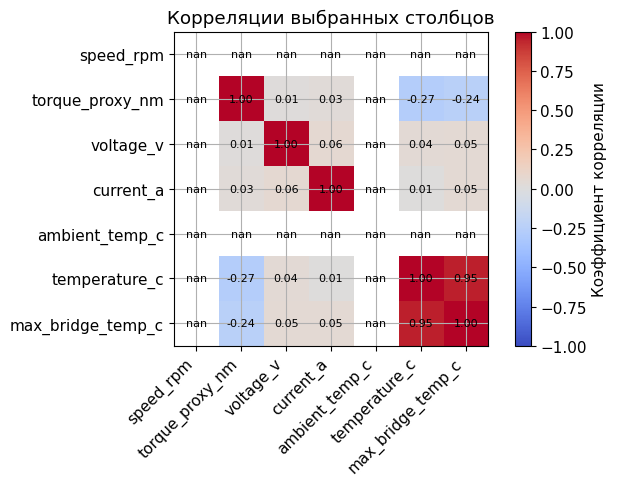

In [8]:
plot_correlation_heatmap(
    features_df,
    [column for column in analysis_columns if column in features_df.columns],
    "Корреляции выбранных столбцов",
)


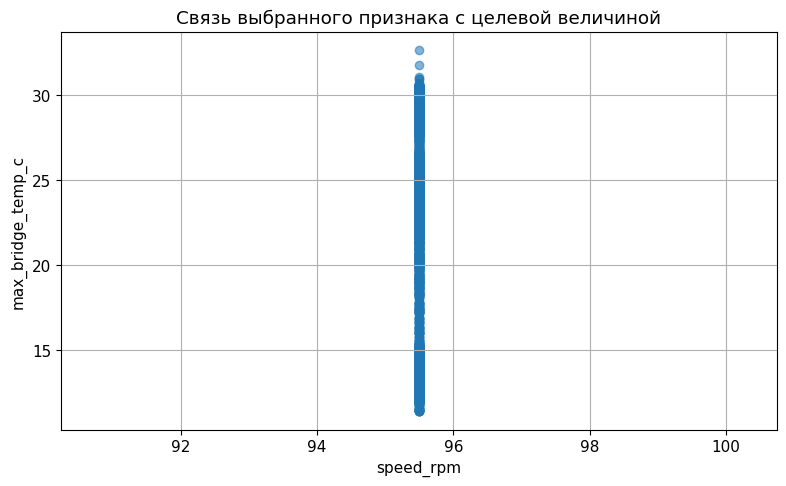

In [9]:
x_column = analysis_columns[0]
y_column = "max_bridge_temp_c"
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(features_df[x_column], features_df[y_column], alpha=0.55)
ax.set_xlabel(x_column)
ax.set_ylabel(y_column)
ax.set_title("Связь выбранного признака с целевой величиной")
plt.tight_layout()
plt.show()


## Задание

1. Опишите источник данных, объект наблюдения и единицу наблюдения.
2. Разделите столбцы на измеряемые, расчетные, служебные и диагностические.
3. Постройте не менее двух графиков и одну таблицу описательной статистики.
4. Объясните, какие столбцы могут привести к утечке данных в занятиях 02-03.
5. Сформулируйте индивидуальный инженерный вывод.
